In [19]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from ydata_profiling import ProfileReport

In [20]:
dataset = pd.read_csv(r'bmw.csv')
dataset.sample(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
1056,2 Series,2017,18950,Automatic,23295,Petrol,200,39.8,3.0
3905,Z4,2019,27950,Semi-Auto,8998,Petrol,145,38.7,2.0
8883,X3,2015,13000,Manual,105320,Diesel,160,52.3,2.0
9958,1 Series,2016,9495,Manual,49000,Petrol,30,56.5,1.5
3896,1 Series,2016,12980,Manual,27696,Diesel,30,65.7,2.0


In [21]:
dataset.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


In [22]:
profile = ProfileReport(dataset, title="BMW Profile info")
profile.to_file("bmw_profile.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 933.34it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
dataset.shape

(10781, 9)

In [24]:

dataset.drop_duplicates(inplace=True)
dataset.shape

(10664, 9)

In [25]:
dataset.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [26]:
dataset.sample(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
5797,1 Series,2019,22890,Manual,10927,Petrol,150,41.5,1.5
4111,3 Series,2015,17491,Semi-Auto,44700,Petrol,265,37.2,3.0
5634,X5,2018,34995,Automatic,26107,Hybrid,135,85.6,2.0
8544,4 Series,2016,17499,Automatic,35399,Diesel,145,55.4,3.0
8050,X3,2015,16348,Automatic,88187,Diesel,200,47.1,3.0


In [27]:
dataset.fuelType.value_counts()

fuelType
Diesel      6988
Petrol      3340
Hybrid       297
Other         36
Electric       3
Name: count, dtype: int64

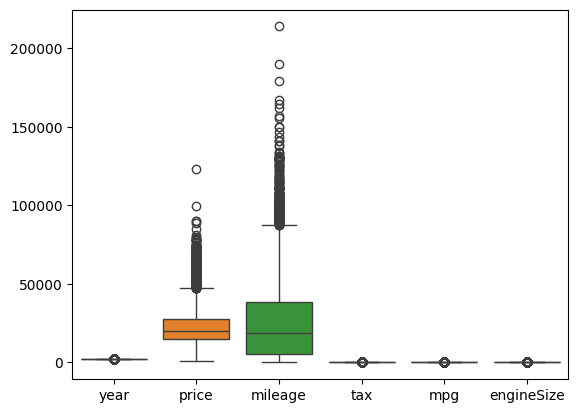

In [28]:
sns.boxplot(dataset)
plt.show()

In [29]:
dataset.select_dtypes(include="object").columns

Index(['model', 'transmission', 'fuelType'], dtype='object')

In [30]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
le = LabelEncoder()

dataset.model = le.fit_transform(dataset.model)
dataset.fuelType = le.fit_transform(dataset.fuelType)
dataset.transmission = le.fit_transform(dataset.transmission)
dataset.sample(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
2260,3,2019,24975,2,11736,0,145,65.7,2.0
9958,0,2016,9495,1,49000,4,30,56.5,1.5
2518,3,2016,19972,2,15705,4,145,48.7,2.0
4789,3,2014,15050,2,26973,0,125,60.1,2.0
1053,1,2015,11495,1,41388,0,20,74.3,1.5


In [31]:
dataset.transmission.value_counts()

transmission
2    4637
0    3542
1    2485
Name: count, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns="price"),
                                                    dataset["price"],
                                                    test_size=0.2,
                                                    random_state=42)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[-0.21906999,  0.81920966, -1.26902098, ...,  0.21900326,
        -0.16053969,  1.49216025],
       [-0.54821511, -0.02662122, -0.11878533, ..., -1.6649586 ,
         0.35305533, -0.30985545],
       [-0.87736024, -0.02662122,  1.03145033, ...,  0.21900326,
        -0.02810324, -1.2108633 ],
       ...,
       [ 1.59122823,  0.81920966,  1.03145033, ...,  0.21900326,
        -0.06686513, -0.30985545],
       [ 1.2620831 ,  0.81920966, -0.11878533, ...,  0.21900326,
        -0.06686513, -1.2108633 ],
       [-0.87736024, -0.87245209, -0.11878533, ..., -1.82878137,
         0.40473785, -0.30985545]], shape=(8531, 8))

In [34]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)
lr.score(X_test_scaled, y_test)*100, lr.score(X_train_scaled, y_train)*100

(74.63349483632562, 74.4236344471225)

In [41]:
from sklearn.metrics import  r2_score, root_mean_squared_error

lr_prd = lr.predict(X_test_scaled)

r2_score(y_test, lr_prd)

0.7463349483632562

In [39]:
root_mean_squared_error(y_test, lr_prd)

5622.038826042802

In [56]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=500,criterion="squared_error",max_depth= 5,random_state=42)
rf.fit(X_train_scaled, y_train)
print(f"Test Score: {rf.score(X_test_scaled, y_test)*100}\nTrain Score:  {rf.score(X_train_scaled, y_train)*100}")
print(f"r2_score: {r2_score(y_test, rf.predict(X_test_scaled))*100}")
print(f"rmse: {root_mean_squared_error(y_test,rf.predict(X_test_scaled))}")

Test Score: 88.19336062698117
Train Score:  89.31196342846317
r2_score: 88.19336062698117
rmse: 3835.5413676224684


In [53]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train_scaled, y_train)
print(f"Test Score: {xgb.score(X_test_scaled, y_test)*100}\nTranning Score: {xgb.score(X_train_scaled, y_train)*100}")
print(f"r2_score: {r2_score(y_test, xgb.predict(X_test_scaled))*100}")
print(f"rmse: {root_mean_squared_error(y_test,xgb.predict(X_test_scaled))}")

Test Score: 95.54444551467896
Tranning Score: 98.41496348381042
r2_score: 95.54444551467896
rmse: 2356.21240234375
